Original data shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Mean after scaling (~0): [-0. -0. -0. -0.]
Std after scaling (~1): [1. 1. 1. 1.]

PCA FROM SCRATCH

Covariance matrix:
 [[ 1.007 -0.118  0.878  0.823]
 [-0.118  1.007 -0.431 -0.369]
 [ 0.878 -0.431  1.007  0.969]
 [ 0.823 -0.369  0.969  1.007]]

Eigenvalues (sorted): [2.938 0.92  0.148 0.021]
Explained variance ratio: [0.73  0.229 0.037 0.005]
Cumulative variance (first 2 components): 0.958

Transformed data shape (from scratch): (150, 2)

PCA USING SCIKIT-LEARN

Explained variance ratio: [0.73  0.229]
Cumulative variance (first 2 components): 0.958
Transformed data shape (sklearn): (150, 2)

Plot saved as pca_iris_result.png

Sanity check passed: scratch implementation matches scikit-learn.


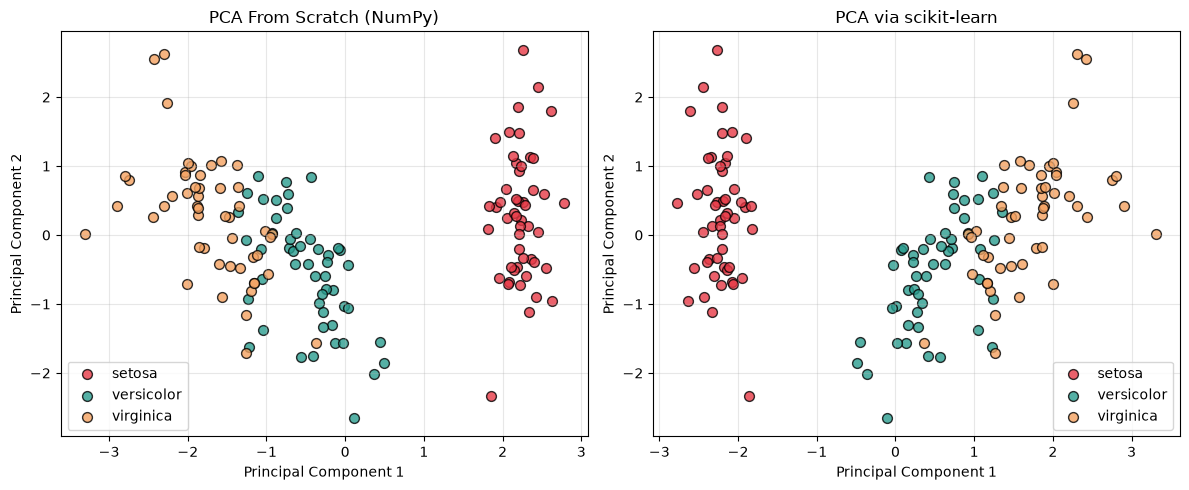

In [3]:
"""
PCA Laboratory Demonstration
============================
This script demonstrates Principal Component Analysis (PCA) in two ways:
  1. Implemented from scratch using NumPy (to understand the math)
  2. Using scikit-learn's PCA class (the practical, production way)

Dataset: The classic Iris dataset (4 features, 150 samples, 3 classes)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------------------------------------------------
# STEP 1: Load the dataset
# -----------------------------------------------------------------------
iris = load_iris()
X = iris.data                # shape (150, 4) -> 4 features
y = iris.target              # class labels (0, 1, 2)
feature_names = iris.feature_names

print("Original data shape:", X.shape)
print("Feature names:", feature_names)

# -----------------------------------------------------------------------
# STEP 2: Standardize the data (mean = 0, std = 1)
# PCA is affected by scale, so features must be standardized first.
# -----------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling (~0):", np.round(X_scaled.mean(axis=0), 3))
print("Std after scaling (~1):", np.round(X_scaled.std(axis=0), 3))

# -----------------------------------------------------------------------
# STEP 3A: PCA FROM SCRATCH (using NumPy)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# 1. Compute the covariance matrix of the standardized data
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance matrix:\n", np.round(cov_matrix, 3))

# 2. Compute eigenvalues and eigenvectors of the covariance matrix
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# 3. Sort eigenvalues (and corresponding eigenvectors) in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("\nEigenvalues (sorted):", np.round(eigen_values, 3))

# 4. Compute explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("Explained variance ratio:", np.round(explained_variance_ratio, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(explained_variance_ratio[:2]), 3))

# 5. Select top k eigenvectors (k=2) to form the projection matrix
k = 2
projection_matrix = eigen_vectors[:, :k]

# 6. Project the standardized data onto the new subspace
X_pca_scratch = X_scaled.dot(projection_matrix)
print("\nTransformed data shape (from scratch):", X_pca_scratch.shape)

# -----------------------------------------------------------------------
# STEP 3B: PCA USING SCIKIT-LEARN (practical approach)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(pca.explained_variance_ratio_), 3))
print("Transformed data shape (sklearn):", X_pca_sklearn.shape)

# -----------------------------------------------------------------------
# STEP 4: Visualize the result
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e63946", "#2a9d8f", "#f4a261"]
target_names = iris.target_names

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch (NumPy)", "PCA via scikit-learn"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0], data[y == i, 1],
            label=target_name, color=colors[i], alpha=0.8, edgecolor="k", s=50
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pca_iris_result.png", dpi=150)
print("\nPlot saved as pca_iris_result.png")

# -----------------------------------------------------------------------
# STEP 5: Sanity check - both methods should give (near) identical variance
# -----------------------------------------------------------------------
assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"
print("\nSanity check passed: scratch implementation matches scikit-learn.")

Original data shape: (178, 13)
Feature names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Mean after scaling: [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
Standard deviation after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

PCA FROM SCRATCH

Covariance Matrix:

[[ 1.006  0.095  0.213 -0.312  0.272  0.291  0.238 -0.157  0.137  0.549
  -0.072  0.073  0.647]
 [ 0.095  1.006  0.165  0.29  -0.055 -0.337 -0.413  0.295 -0.222  0.25
  -0.564 -0.371 -0.193]
 [ 0.213  0.165  1.006  0.446  0.288  0.13   0.116  0.187  0.01   0.26
  -0.075  0.004  0.225]
 [-0.312  0.29   0.446  1.006 -0.084 -0.323 -0.353  0.364 -0.198  0.019
  -0.276 -0.278 -0.443]
 [ 0.272 -0.055  0.288 -0.084  1.006  0.216  0.197 -0.258  0.238  0.201
   0.056  0.066  0.396]
 [ 0.291 -0.337  0.13  -0.323  0.216  1.006  0.869 -0.452  0.616 -0.055
   0.

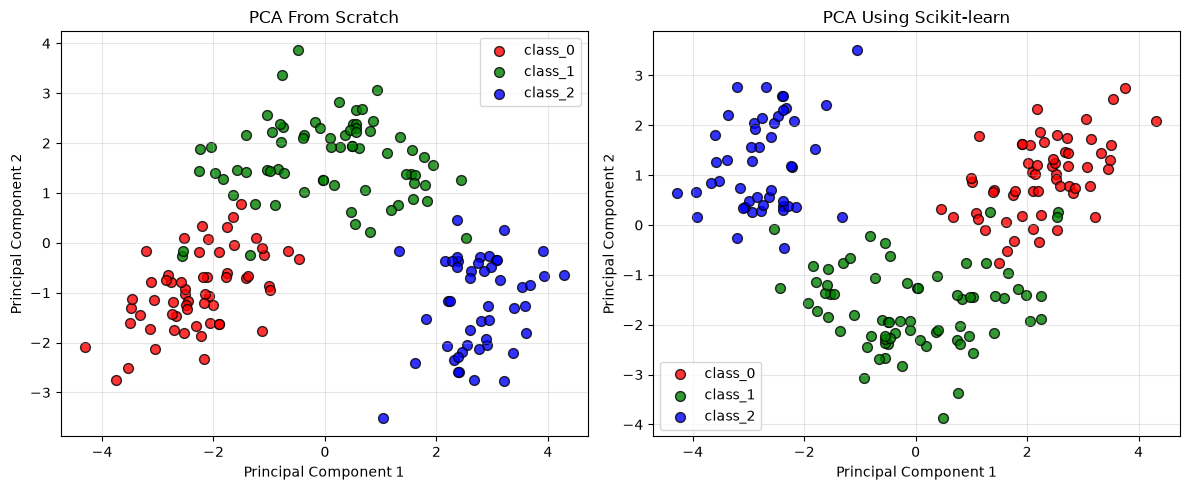

In [5]:
"""
PCA Laboratory Demonstration on Wine Dataset
============================================
This program shows Principal Component Analysis (PCA) in two ways:
1. PCA from scratch using NumPy
2. PCA using scikit-learn

Dataset: Wine Dataset
13 features, 178 samples, 3 classes
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------------------------------------------------
# STEP 1: Load the Wine dataset
# -----------------------------------------------------------------------
wine = load_wine()

X = wine.data              # Feature values
y = wine.target            # Class labels
feature_names = wine.feature_names

print("Original data shape:", X.shape)
print("Feature names:")
print(feature_names)

# -----------------------------------------------------------------------
# STEP 2: Standardize the data
# PCA works better when all features have same scale.
# So we convert every feature to mean = 0 and std = 1.
# -----------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling:", np.round(X_scaled.mean(axis=0), 3))
print("Standard deviation after scaling:", np.round(X_scaled.std(axis=0), 3))

# -----------------------------------------------------------------------
# STEP 3A: PCA FROM SCRATCH
# -----------------------------------------------------------------------
print("\n" + "="*60)
print("PCA FROM SCRATCH")
print("="*60)

# Calculate covariance matrix
# It tells us how features vary together.
cov_matrix = np.cov(X_scaled.T)

print("\nCovariance Matrix:\n")
print(np.round(cov_matrix, 3))

# Find eigenvalues and eigenvectors
# Eigenvalues tell importance of each principal component.
# Eigenvectors tell the direction of each principal component.
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues in descending order
sorted_index = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]

print("\nEigenvalues:")
print(np.round(eigen_values, 3))

# Calculate explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)

print("\nExplained Variance Ratio:")
print(np.round(explained_variance_ratio, 3))

print("Variance explained by first 2 components:",
      np.round(np.sum(explained_variance_ratio[:2]), 3))

# Select first 2 principal components
k = 2
projection_matrix = eigen_vectors[:, :k]

# Transform the data into new feature space
X_pca_scratch = X_scaled.dot(projection_matrix)

print("\nShape after PCA (Scratch):", X_pca_scratch.shape)

# -----------------------------------------------------------------------
# STEP 3B: PCA USING SCIKIT-LEARN
# -----------------------------------------------------------------------
print("\n" + "="*60)
print("PCA USING SCIKIT-LEARN")
print("="*60)

pca = PCA(n_components=2)

# Fit PCA and transform the data
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio:")
print(np.round(pca.explained_variance_ratio_, 3))

print("Variance explained by first 2 components:",
      np.round(np.sum(pca.explained_variance_ratio_), 3))

print("Shape after PCA (Scikit-learn):", X_pca_sklearn.shape)

# -----------------------------------------------------------------------
# STEP 4: Plot the transformed data
# -----------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["red", "green", "blue"]
target_names = wine.target_names

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch", "PCA Using Scikit-learn"]
):

    for i, target_name in enumerate(target_names):

        ax.scatter(
            data[y == i, 0],
            data[y == i, 1],
            color=colors[i],
            label=target_name,
            edgecolor="black",
            s=50,
            alpha=0.8
        )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

# Save the figure
plt.savefig("pca_wine_result.png", dpi=150)

print("\nPlot saved as pca_wine_result.png")

# -----------------------------------------------------------------------
# STEP 5: Compare both methods
# Both implementations should give same variance values.
# -----------------------------------------------------------------------

assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6
), "Scratch PCA and Scikit-learn PCA do not match!"

print("\nSanity Check Passed!")
print("Both implementations produce almost identical results.")